In [1]:
## 1. Preamble - Kaggle, seeds, output dirs
from kaggle_secrets import UserSecretsClient
import os
try:
    os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    pass

import random, numpy as np, torch
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

os.system("df -h /")

RUN_NAME    = "tier2_b_s10"
PRECOMP_DIR = "/kaggle/input/datasets/antoniogatovski/slavic-lid-precomp"
WORK_ROOT   = "/kaggle/working/slavic_lid"
CKPT_DIR    = f"{WORK_ROOT}/ckpts/{RUN_NAME}"
LOG_DIR     = f"{WORK_ROOT}/logs/{RUN_NAME}"
RES_DIR     = f"{WORK_ROOT}/results/{RUN_NAME}"
for d in (CKPT_DIR, LOG_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

LANGS = ['be', 'bg', 'cs', 'mk', 'pl', 'ru', 'sr', 'uk']
NUM_CLASSES = len(LANGS)
print("output dirs ready under", WORK_ROOT)

device: cuda
gpu: Tesla T4
Filesystem      Size  Used Avail Use% Mounted on
overlay         7.9T  6.8T  1.1T  87% /
output dirs ready under /kaggle/working/slavic_lid


In [2]:
import os
os.system("find /kaggle/input -type f -name '*.npy'")

/kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/train_labels.npy
/kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/test_labels.npy
/kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/test_mels.npy
/kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/train_mels.npy
/kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/fleurs_labels.npy
/kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/fleurs_mels.npy


0

In [3]:
# ## 2. Load HF dataset to VM disk

# Downloads ~22 GB to `/root/.cache/huggingface` (VM only, wiped on disconnect - that's fine).
# ~5-10 min the first time. **Skipped if the precomp files already exist on Drive**
# (no point downloading raw audio we don't need).
_have_precomp = all(
    os.path.exists(f"{PRECOMP_DIR}/{split}_{kind}.npy")
    for split in ("train", "test", "fleurs")
    for kind in ("mels", "labels")
)

ds = None
if _have_precomp:
    print("precomp exists, skipping HF dataset download.")
else:
    print("does not exist")


precomp exists, skipping HF dataset download.


In [4]:
# ## 3. Precompute log-Mel features to Drive (one-time, ~25 min)

# Why precompute: CPU-side audio decoding inside the DataLoader was the
# 30 min/epoch wall on Account 1. Precomputing once -> ~3 min/epoch from then on.

# - 64 mels, 25 ms window, 10 ms hop -> shape (64, 301) per 3 s clip.
# - Saved as float16: train 3.08 GB, test 4.14 GB, fleurs ~80 MB.
# - The `os.path.exists` guard makes this cell a no-op on rerun.
# - FLEURS clips are 5-27 s - we truncate/zero-pad to exactly 48000 samples first.
import numpy as np, torch, torch.nn as nn
import torchaudio.transforms as _T_pre
from tqdm import tqdm

SR = 16000
N_MELS = 64
N_FFT = 400      # 25 ms
HOP   = 160      # 10 ms
TARGET_LEN = SR * 3   # 48000 samples = 3.0 s
N_FRAMES = 301

class _LogMel(nn.Module):
    def __init__(self):
        super().__init__()
        self.mel = _T_pre.MelSpectrogram(
            sample_rate=SR, n_fft=N_FFT, hop_length=HOP, win_length=N_FFT,
            n_mels=N_MELS, f_min=0.0, f_max=SR/2, power=2.0,
        )
    def forward(self, x):
        m = torch.log(self.mel(x) + 1e-6)
        mu  = m.mean(dim=(1, 2), keepdim=True)
        std = m.std (dim=(1, 2), keepdim=True) + 1e-5
        return (m - mu) / std

def _fix_length(arr, target=TARGET_LEN):
    if len(arr) >= target:
        return arr[:target]
    out = np.zeros(target, dtype=np.float32)
    out[:len(arr)] = arr
    return out

def _precompute(split_name, hf_split, out_prefix, batch=256):
    mels_path   = f"{PRECOMP_DIR}/{out_prefix}_mels.npy"
    labels_path = f"{PRECOMP_DIR}/{out_prefix}_labels.npy"
    if os.path.exists(mels_path) and os.path.exists(labels_path):
        print(f"[{split_name}] precomp exists, skipping.")
        return
    if hf_split is None:
        raise RuntimeError(f"[{split_name}] dataset not loaded - re-run Cell 2.")
    n = len(hf_split)
    mels   = np.zeros((n, N_MELS, N_FRAMES), dtype=np.float16)
    labels = np.zeros(n, dtype=np.int64)
    print(f"[{split_name}] precomputing {n} clips ...")
    logmel_local = _LogMel().to(DEVICE)
    with torch.no_grad():
        for i in tqdm(range(0, n, batch)):
            chunk = hf_split[i:i+batch]
            wavs = np.stack([_fix_length(np.asarray(a["array"], dtype=np.float32))
                             for a in chunk["audio"]])
            wavs_t = torch.from_numpy(wavs).to(DEVICE)
            m = logmel_local(wavs_t).cpu().numpy().astype(np.float16)
            mels[i:i+len(m)]   = m
            labels[i:i+len(m)] = np.asarray(chunk["label"], dtype=np.int64)
    np.save(mels_path,   mels)
    np.save(labels_path, labels)
    print(f"[{split_name}] saved {mels.nbytes/1e9:.2f} GB -> {mels_path}")

if ds is None:
    print("precomp already on Drive, nothing to do.")
else:
    _precompute("train",  ds["train"],       "train")
    _precompute("test",   ds["test"],        "test")
    _precompute("fleurs", ds["eval_fleurs"], "fleurs")

get_ipython().system('ls -lh ' + PRECOMP_DIR)


precomp already on Drive, nothing to do.
total 7.0G
-rw-r--r-- 1 nobody nogroup  49K Jun 19 16:30 fleurs_labels.npy
-rw-r--r-- 1 nobody nogroup 227M Jun 19 16:30 fleurs_mels.npy
-rw-r--r-- 1 nobody nogroup 840K Jun 19 16:30 test_labels.npy
-rw-r--r-- 1 nobody nogroup 3.9G Jun 19 16:31 test_mels.npy
-rw-r--r-- 1 nobody nogroup 626K Jun 19 16:30 train_labels.npy
-rw-r--r-- 1 nobody nogroup 2.9G Jun 19 16:31 train_mels.npy


In [5]:
## 4. Pre-flight: confirm precomp on Drive
for split in ("train", "test", "fleurs"):
    for kind in ("mels", "labels"):
        p = f"{PRECOMP_DIR}/{split}_{kind}.npy"
        assert os.path.exists(p), f"MISSING: {p} - re-run Cells 2-3"
        print(f"OK  {p}  ({os.path.getsize(p)/1e9:.2f} GB)")


OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/train_mels.npy  (3.08 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/train_labels.npy  (0.00 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/test_mels.npy  (4.14 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/test_labels.npy  (0.00 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/fleurs_mels.npy  (0.24 GB)
OK  /kaggle/input/datasets/antoniogatovski/slavic-lid-precomp/fleurs_labels.npy  (0.00 GB)


In [6]:
# ## 5. MelDataset (mmap) + SpecAugment + AAM-Softmax head

# AAM-Softmax notes (CLAUDE.md §5.3):
# - It's a **head**, not a model. Replaces the final `Linear -> CE` with a margin classifier.
# - L2-normalize features and weights, compute `cos(theta_yi) = w_yi^T x_i`.
# - During training, push the target-class logit to `cos(theta + m)` (angular margin), scale all logits by `s`, then plain CE.
# - During eval, use `s * cos(theta)` (no margin) and `argmax`.
# - m=0.2, s=30 are the standard speaker-verification values; project brief specifies them.
import math
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset

class MelDataset(Dataset):
    def __init__(self, prefix):
        self.mels   = np.load(f"{PRECOMP_DIR}/{prefix}_mels.npy",   mmap_mode="r")
        self.labels = np.load(f"{PRECOMP_DIR}/{prefix}_labels.npy", mmap_mode="r")
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        m = torch.from_numpy(np.asarray(self.mels[i], dtype=np.float32))  # (64, 301)
        y = int(self.labels[i])
        return m, y

class SpecAugment(nn.Module):
    def __init__(self, freq_mask=15, time_mask=30, n_freq=2, n_time=2):
        super().__init__()
        self.fm = T.FrequencyMasking(freq_mask)
        self.tm = T.TimeMasking(time_mask)
        self.n_freq, self.n_time = n_freq, n_time
    def forward(self, x):
        if not self.training: return x
        for _ in range(self.n_freq): x = self.fm(x)
        for _ in range(self.n_time): x = self.tm(x)
        return x

specaug = SpecAugment().to(DEVICE)


class AAMSoftmax(nn.Module):
    # Additive Angular Margin (ArcFace) head.
    # forward(x, y) at train time applies the angular margin on the target class;
    # forward(x) at eval returns plain s*cos(theta).
    def __init__(self, in_features, n_classes, m=0.2, s=10.0):
        super().__init__()
        self.m, self.s = m, s
        self.W = nn.Parameter(torch.empty(n_classes, in_features))
        nn.init.xavier_normal_(self.W)
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th    = math.cos(math.pi - m)
        self.mm    = math.sin(math.pi - m) * m

    def forward(self, x, y=None):
        x_n = F.normalize(x,        dim=1)
        W_n = F.normalize(self.W,   dim=1)
        cos = F.linear(x_n, W_n).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        if y is None:
            return self.s * cos
        sin   = torch.sqrt(1.0 - cos * cos)
        cos_t = cos * self.cos_m - sin * self.sin_m
        cos_t = torch.where(cos > self.th, cos_t, cos - self.mm)
        onehot = torch.zeros_like(cos).scatter_(1, y.view(-1, 1), 1.0)
        logits = onehot * cos_t + (1.0 - onehot) * cos
        return self.s * logits

# Smoke test
_d = MelDataset("train")
print("train samples:", len(_d), "first shape:", _d[0][0].shape, "label:", _d[0][1])
_h = AAMSoftmax(8, NUM_CLASSES).to(DEVICE)
_z = torch.randn(4, 8, device=DEVICE)
_y = torch.tensor([0, 3, 5, 7], device=DEVICE)
print("AAM train logits:", _h(_z, _y).shape, "eval logits:", _h(_z).shape)
del _h


train samples: 80000 first shape: torch.Size([64, 301]) label: 0
AAM train logits: torch.Size([4, 8]) eval logits: torch.Size([4, 8])


In [7]:
# ## 6. Model - CNN frontend + 4-layer Transformer + attentive stats pooling

# - **Frontend.** Two conv blocks pool only along the frequency axis (kernel (2,1)).
#   Mels go (B,1,64,301) -> (B,128,16,301). We then collapse channel x freq into a
#   single feature vector per time step -> (B, T=301, d_model=192) via a linear projection.
# - **Transformer.** 4 layers, d_model=192, heads=4, dim_ff=768, dropout=0.1. Pre-LN
#   via `norm_first=True` for stable training.
# - **Attentive statistics pooling.** Per-step attention weights -> weighted mean
#   and weighted std (concat -> 384-d embedding). Standard in speaker verification
#   (X-vectors, ECAPA-TDNN). Pairs naturally with AAM-Softmax.
# - Total params land around ~2-3 M, comfortable on T4 at batch=128 with AMP.
class PositionalEncoding(nn.Module):
    # Fixed sinusoidal PE, added to token embeddings.
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class AttentiveStatsPool(nn.Module):
    # Self-attentive statistics pooling (Okabe et al., 2018). Returns (B, 2*d).
    def __init__(self, d_model, attn_dim=128):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(d_model, attn_dim), nn.Tanh(),
                                  nn.Linear(attn_dim, 1))
    def forward(self, x):
        a = self.proj(x).softmax(dim=1)
        mu  = (a * x).sum(dim=1)
        var = (a * (x - mu.unsqueeze(1)) ** 2).sum(dim=1).clamp(min=1e-8)
        return torch.cat([mu, var.sqrt()], dim=1)


class Tier2Encoder(nn.Module):
    def __init__(self, n_mels=64, d_model=192, nhead=4, nlayers=4, dim_ff=768, dropout=0.1):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
                nn.BatchNorm2d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool2d((2, 1)),
            )
        self.frontend = nn.Sequential(block(1, 64), block(64, 128))
        flat_dim = 128 * (n_mels // 4)
        self.proj = nn.Linear(flat_dim, d_model)
        self.pe   = PositionalEncoding(d_model, max_len=512)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True, activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.pool = AttentiveStatsPool(d_model)
        self.embed_dim = 2 * d_model
        self.bn   = nn.BatchNorm1d(self.embed_dim)

    def features(self, mel):
        h = self.frontend(mel.unsqueeze(1))
        b, c, f, t = h.shape
        h = h.permute(0, 3, 1, 2).reshape(b, t, c * f)
        h = self.proj(h)
        h = self.pe(h)
        h = self.transformer(h)
        h = self.pool(h)
        return self.bn(h)


class Tier2Model(nn.Module):
    # Encoder + AAM-Softmax head.
    def __init__(self, n_classes=NUM_CLASSES, d_model=192, m=0.2, s=10.0):
        super().__init__()
        self.encoder = Tier2Encoder(d_model=d_model)
        self.head    = AAMSoftmax(self.encoder.embed_dim, n_classes, m=m, s=s)

    def forward(self, mel, y=None):
        z = self.encoder.features(mel)
        return self.head(z, y)

    def features(self, mel):
        return self.encoder.features(mel)

_m = Tier2Model().to(DEVICE)
print(f"params: {sum(p.numel() for p in _m.parameters()):,}")
with torch.no_grad():
    out = _m(torch.randn(2, 64, 301, device=DEVICE), torch.tensor([0, 1], device=DEVICE))
print("train logits shape:", out.shape)
del _m


params: 2,276,225


/tmp/ipykernel_23/443662608.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=nlayers)


train logits shape: torch.Size([2, 8])


In [8]:
# ## 7. Debug run - 1k train x 500 test, 2 epochs (~2 min)

# **Sanity gate.** Loss must decrease, test acc must clear 1/8 = 0.125, no NaNs/OOMs.
# AAM-Softmax loss starts higher than vanilla CE (logits scaled by s=30) -
# expect ~3-4 at init, dropping to ~1-2 by end of epoch 2 on the subset.
debug_train = Subset(MelDataset("train"), list(range(1000)))
debug_test  = Subset(MelDataset("test"),  list(range(500)))
dtl = DataLoader(debug_train, batch_size=64,  shuffle=True,  num_workers=2, pin_memory=True)
dvl = DataLoader(debug_test,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

model   = Tier2Model().to(DEVICE)
opt     = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(2):
    model.train(); specaug.train()
    correct, total, lsum = 0, 0, 0.0
    for mel, y in dtl:
        mel = mel.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        mel = specaug(mel)
        logits = model(mel, y)
        loss   = loss_fn(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        lsum    += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
    print(f"[debug] ep{epoch} train loss={lsum/total:.3f} acc={correct/total:.3f}")

    model.eval(); specaug.eval()
    ec, et = 0, 0
    with torch.no_grad():
        for mel, y in dvl:
            mel, y = mel.to(DEVICE), y.to(DEVICE)
            ec += (model(mel).argmax(1) == y).sum().item(); et += y.size(0)
    print(f"[debug] ep{epoch} test acc={ec/et:.3f}")

print("\n--- DEBUG RUN COMPLETE - only proceed if loss dropped and test acc > 0.125 ---")


/tmp/ipykernel_23/443662608.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=nlayers)


[debug] ep0 train loss=2.920 acc=0.430
[debug] ep0 test acc=0.792
[debug] ep1 train loss=1.681 acc=0.809
[debug] ep1 test acc=0.776

--- DEBUG RUN COMPLETE - only proceed if loss dropped and test acc > 0.125 ---


In [9]:
# ## 8. Full training run - 15 epochs, ~50 min on T4

# - Optimizer: AdamW(3e-4, wd=1e-4), cosine schedule with 1-epoch linear warmup.
# - AMP via `torch.amp.GradScaler('cuda')` and `autocast('cuda')`.
# - Best-by-test-macro checkpoint to Drive.
import time
from torch.utils.tensorboard import SummaryWriter

EPOCHS  = 15
BATCH   = 128
LR      = 3e-4
WD      = 1e-4
WARMUP  = 1

train_loader  = DataLoader(MelDataset("train"),  batch_size=BATCH, shuffle=True,
                           num_workers=4, pin_memory=True, drop_last=True)
test_loader   = DataLoader(MelDataset("test"),   batch_size=256,   shuffle=False,
                           num_workers=4, pin_memory=True)
fleurs_loader = DataLoader(MelDataset("fleurs"), batch_size=256,   shuffle=False,
                           num_workers=4, pin_memory=True)

model   = Tier2Model().to(DEVICE)
opt     = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

steps_per_ep = len(train_loader)
total_steps  = EPOCHS * steps_per_ep
warmup_steps = WARMUP * steps_per_ep
def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    p = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * p))
sched   = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

loss_fn = nn.CrossEntropyLoss()
scaler  = torch.amp.GradScaler('cuda')
writer  = SummaryWriter(LOG_DIR)

best_macro = -1.0
for epoch in range(EPOCHS):
    t0 = time.time()
    model.train(); specaug.train()
    lsum, correct, total = 0.0, 0, 0
    for mel, y in train_loader:
        mel = mel.to(DEVICE, non_blocking=True)
        y   = y.to(DEVICE, non_blocking=True)
        mel = specaug(mel)
        with torch.amp.autocast('cuda'):
            logits = model(mel, y)
            loss   = loss_fn(logits, y)
        opt.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(opt); scaler.update(); sched.step()
        lsum    += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item(); total += y.size(0)
    train_loss = lsum / total; train_acc = correct / total

    model.eval()
    pl_c = np.zeros(NUM_CLASSES); pl_t = np.zeros(NUM_CLASSES)
    ec, et = 0, 0
    with torch.no_grad():
        for mel, y in test_loader:
            mel, y = mel.to(DEVICE), y.to(DEVICE)
            pred = model(mel).argmax(1)
            ec += (pred == y).sum().item(); et += y.size(0)
            for c in range(NUM_CLASSES):
                m = (y == c)
                pl_t[c] += m.sum().item()
                pl_c[c] += ((pred == y) & m).sum().item()
    micro = ec / et
    macro = (pl_c / np.maximum(pl_t, 1)).mean()

    dt = time.time() - t0
    print(f"ep{epoch:02d} dt={dt:.0f}s lr={sched.get_last_lr()[0]:.2e} | "
          f"train loss={train_loss:.3f} acc={train_acc:.3f} | "
          f"test micro={micro:.3f} macro={macro:.3f}")
    writer.add_scalar("train/loss", train_loss, epoch)
    writer.add_scalar("train/acc",  train_acc,  epoch)
    writer.add_scalar("test/micro", micro,      epoch)
    writer.add_scalar("test/macro", macro,      epoch)
    writer.add_scalar("lr",         sched.get_last_lr()[0], epoch)
    for c, lg in enumerate(LANGS):
        writer.add_scalar(f"test_per_lang/{lg}", pl_c[c] / max(pl_t[c], 1), epoch)

    if macro > best_macro:
        best_macro = macro
        torch.save({"model": model.state_dict(), "epoch": epoch, "macro": macro,
                    "config": {"epochs": EPOCHS, "batch": BATCH, "lr": LR, "wd": WD,
                               "loss": "AAM-Softmax", "m": 0.2, "s": 10.0,
                               "d_model": 192, "nhead": 4, "nlayers": 4,
                               "warmup_epochs": WARMUP, "seed": SEED}},
                   f"{CKPT_DIR}/best.pt")
        print(f"  -> new best, saved (macro={macro:.3f})")

writer.close()
print(f"\nDONE. best test macro = {best_macro:.3f}")

2026-06-19 16:57:43.631995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781888263.794295      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781888263.841462      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781888264.226888      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781888264.226946      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781888264.226953      23 computation_placer.cc:177] computation placer alr

ep00 dt=303s lr=3.00e-04 | train loss=2.864 acc=0.190 | test micro=0.267 macro=0.260
  -> new best, saved (macro=0.260)
ep01 dt=309s lr=2.96e-04 | train loss=2.033 acc=0.405 | test micro=0.342 macro=0.243
ep02 dt=308s lr=2.85e-04 | train loss=1.612 acc=0.520 | test micro=0.337 macro=0.302
  -> new best, saved (macro=0.302)
ep03 dt=309s lr=2.67e-04 | train loss=1.369 acc=0.590 | test micro=0.409 macro=0.277
ep04 dt=308s lr=2.44e-04 | train loss=1.189 acc=0.640 | test micro=0.400 macro=0.281
ep05 dt=308s lr=2.15e-04 | train loss=1.046 acc=0.682 | test micro=0.422 macro=0.273
ep06 dt=308s lr=1.83e-04 | train loss=0.931 acc=0.717 | test micro=0.417 macro=0.278
ep07 dt=308s lr=1.50e-04 | train loss=0.846 acc=0.744 | test micro=0.425 macro=0.306
  -> new best, saved (macro=0.306)
ep08 dt=309s lr=1.17e-04 | train loss=0.747 acc=0.774 | test micro=0.423 macro=0.286
ep09 dt=308s lr=8.49e-05 | train loss=0.665 acc=0.795 | test micro=0.427 macro=0.279
ep10 dt=308s lr=5.65e-05 | train loss=0.597 a

In [ ]:
# ## 9. Final eval + artifacts

# Loads `best.pt`, evaluates on `test` and `eval_fleurs`, dumps:
# - `metrics.json` (micro/macro/macro_f1/per-language)
# - `test_predictions.csv`
# - `cm_test.png`, `cm_eval_fleurs.png`
import json, csv
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

ckpt = torch.load(f"{CKPT_DIR}/best.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"]); model.eval()
print(f"loaded best: epoch {ckpt['epoch']}, macro={ckpt['macro']:.3f}")

def evaluate(loader, name):
    preds, trues = [], []
    with torch.no_grad():
        for mel, y in loader:
            mel = mel.to(DEVICE)
            preds.append(model(mel).argmax(1).cpu().numpy())
            trues.append(y.numpy())
    p = np.concatenate(preds); t = np.concatenate(trues)
    cm = confusion_matrix(t, p, labels=list(range(NUM_CLASSES)))
    pl = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    micro = (p == t).mean(); macro = pl.mean()
    report = classification_report(t, p, target_names=LANGS, digits=3, zero_division=0, output_dict=True)
    macro_f1 = report["macro avg"]["f1-score"]
    print(f"\n[{name}] micro={micro:.3f} macro_acc={macro:.3f} macro_f1={macro_f1:.3f}")
    print(classification_report(t, p, target_names=LANGS, digits=3, zero_division=0))
    return {"name": name, "micro": float(micro), "macro": float(macro), "macro_f1": float(macro_f1),
            "per_lang": {lg: float(a) for lg, a in zip(LANGS, pl)},
            "per_lang_f1": {lg: float(report[lg]["f1-score"]) for lg in LANGS},
            "cm": cm.tolist(), "pred": p.tolist(), "true": t.tolist()}

results = {n: evaluate(l, n) for n, l in
           [("test", test_loader), ("eval_fleurs", fleurs_loader)]}

with open(f"{RES_DIR}/metrics.json", "w") as f:
    json.dump({n: {k: v for k, v in r.items() if k not in ("pred", "true")}
               for n, r in results.items()}, f, indent=2)

with open(f"{RES_DIR}/test_predictions.csv", "w", newline="") as f:
    w = csv.writer(f); w.writerow(["true", "pred", "true_lang", "pred_lang"])
    for tt, pp in zip(results["test"]["true"], results["test"]["pred"]):
        w.writerow([tt, pp, LANGS[tt], LANGS[pp]])

for name, r in results.items():
    cm = np.array(r["cm"])
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(LANGS)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(LANGS)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{RUN_NAME} - {name} (macro_f1={r['macro_f1']:.3f})")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                    color="white" if cmn[i,j] > 0.5 else "black", fontsize=8)
    plt.colorbar(im, ax=ax); plt.tight_layout()
    plt.savefig(f"{RES_DIR}/cm_{name}.png", dpi=150); plt.show()

print(f"\nartifacts -> {RES_DIR}")


In [ ]:
# ## Restore loaders (run this instead of the training cell after a session disconnect)
# Re-creates test_loader and fleurs_loader from precomp .npy files.
# Also initialises a fresh model so the eval cell can load_state_dict from best.pt.
# Skip this cell if you just finished training in the same session.
test_loader   = DataLoader(MelDataset("test"),   batch_size=256, shuffle=False,
                           num_workers=4, pin_memory=True)
fleurs_loader = DataLoader(MelDataset("fleurs"), batch_size=256, shuffle=False,
                           num_workers=4, pin_memory=True)
model = Tier2Model().to(DEVICE)
print("loaders and model ready — proceed to eval cell")


t-SNE sample size: 1000
embeddings: (1000, 384)


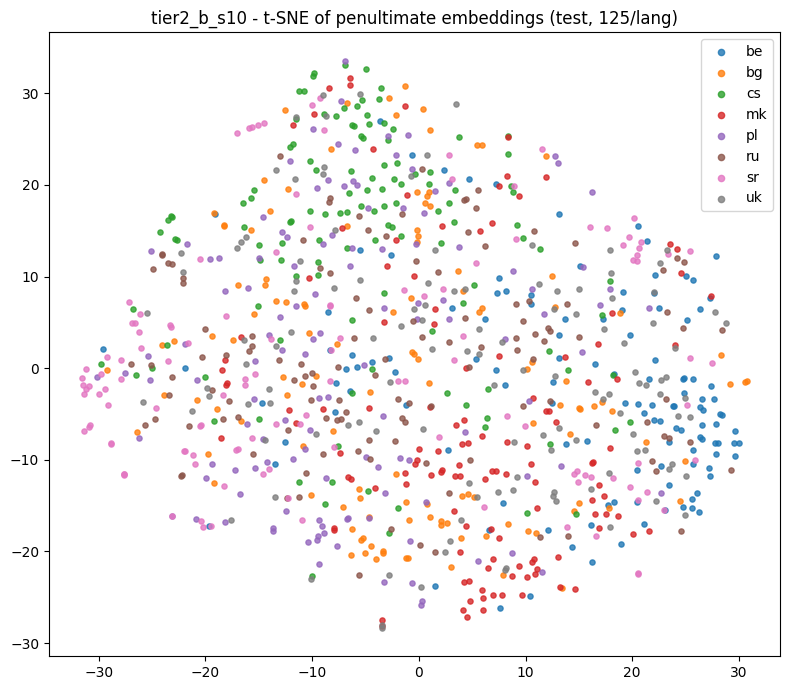

saved -> /kaggle/working/slavic_lid/results/tier2_b_s10/tsne_test.png


In [11]:
## 10. t-SNE of penultimate-layer (post-pool, pre-AAM) embeddings
from sklearn.manifold import TSNE

test_labels_full = np.load(f"{PRECOMP_DIR}/test_labels.npy", mmap_mode="r")
rng = np.random.default_rng(SEED)
idxs = []
for c in range(NUM_CLASSES):
    cls_idx = np.where(test_labels_full[:] == c)[0]
    idxs.append(rng.choice(cls_idx, size=min(125, len(cls_idx)), replace=False))
sample_idx = np.concatenate(idxs)
print("t-SNE sample size:", len(sample_idx))

tsne_loader = DataLoader(Subset(MelDataset("test"), sample_idx.tolist()),
                         batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

embs, labs = [], []
model.eval()
with torch.no_grad():
    for mel, y in tsne_loader:
        mel = mel.to(DEVICE)
        embs.append(model.features(mel).cpu().numpy())
        labs.append(y.numpy())
E = np.concatenate(embs); Y = np.concatenate(labs)
print("embeddings:", E.shape)

Z = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED).fit_transform(E)

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.get_cmap("tab10")
for c in range(NUM_CLASSES):
    m = (Y == c)
    ax.scatter(Z[m, 0], Z[m, 1], s=14, alpha=0.8, color=cmap(c), label=LANGS[c])
ax.set_title(f"{RUN_NAME} - t-SNE of penultimate embeddings (test, 125/lang)")
ax.legend(loc="best", markerscale=1.2)
plt.tight_layout()
plt.savefig(f"{RES_DIR}/tsne_test.png", dpi=150)
plt.show()
print(f"saved -> {RES_DIR}/tsne_test.png")
